<h2>ЛР 2 Проведение экспериментов по настройке модели

In [4]:
import os

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

import matplotlib.pyplot as plt

<h3>Разбиваем выборку

In [5]:
df = pd.read_pickle('../data/clean_data.pkl')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Major_Category              50000 non-null  category
 1   Year_of_Study               50000 non-null  category
 2   Pre_Semester_GPA            50000 non-null  float32 
 3   Weekly_GenAI_Hours          50000 non-null  float32 
 4   Primary_Use_Case            50000 non-null  category
 5   Prompt_Engineering_Skill    50000 non-null  category
 6   Tool_Diversity              50000 non-null  int8    
 7   Paid_Subscription           50000 non-null  bool    
 8   Traditional_Study_Hours     50000 non-null  float32 
 9   Perceived_AI_Dependency     50000 non-null  int8    
 10  Institutional_Policy        50000 non-null  category
 11  Anxiety_Level_During_Exams  50000 non-null  int8    
 12  Post_Semester_GPA           50000 non-null  float32 
 13  Skill_Retention_

In [6]:
df = df.rename(columns={"Post_Semester_GPA" : "target"})
df = df.drop(columns=['GPA_Delta', 'AI_Usage_Group', 'AI_Usage_Percentage', 'Total_Stud_Hours', 'Academic_Perfomance_Drop'])
df

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,target,Skill_Retention_Score,Burnout_Risk_Level,High_Risk_Student
0,Humanities,Senior,2.418,23.309999,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.440002,High,False
1,Medical,Junior,3.821,1.120000,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.389999,Low,False
2,Business,Freshman,3.398,21.260000,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.930000,Medium,False
3,Business,Senior,3.789,1.820000,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.580002,Medium,False
4,STEM,Sophomore,3.635,9.290000,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.000000,Medium,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Business,Senior,2.899,12.160000,Copywriting/Drafting,Beginner,2,False,13.36,2,Allowed_With_Citation,2,3.584,66.160004,High,False
49996,STEM,Senior,2.870,2.510000,Copywriting/Drafting,Intermediate,1,False,4.67,3,Actively_Encouraged,3,3.096,81.620003,Medium,False
49997,Business,Senior,3.177,15.870000,Summarizing_Reading,Advanced,5,True,3.92,4,Allowed_With_Citation,5,3.605,97.209999,High,False
49998,Business,Junior,3.398,19.910000,Debugging/Troubleshooting,Intermediate,5,False,7.10,5,Allowed_With_Citation,3,3.527,84.120003,Medium,False


In [7]:
X_train, X_test, y_train, y_test = train_test_split(df.drop("target",axis=1), df['target'], test_size=0.25, random_state=42)

In [8]:
X_train.iloc[0]

Major_Category                               STEM
Year_of_Study                              Senior
Pre_Semester_GPA                            3.074
Weekly_GenAI_Hours                           3.04
Primary_Use_Case                         Ideation
Prompt_Engineering_Skill                 Beginner
Tool_Diversity                                  1
Paid_Subscription                           False
Traditional_Study_Hours                      20.6
Perceived_AI_Dependency                         2
Institutional_Policy          Actively_Encouraged
Anxiety_Level_During_Exams                      2
Skill_Retention_Score                   88.699997
Burnout_Risk_Level                         Medium
High_Risk_Student                           False
Name: 27434, dtype: object

In [9]:
cat_features = X_train.select_dtypes(include=['category','object']).columns.to_list()
cat_features

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Institutional_Policy',
 'Burnout_Risk_Level']

In [10]:
num_features = X_train.select_dtypes(include=['number']).columns.to_list()
num_features

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Skill_Retention_Score']

In [11]:
s_scaler = StandardScaler()
l_encoder = OrdinalEncoder()
regressor = CatBoostRegressor()

In [12]:
# Для удобной работы со столбцами
preprocessor = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
    ],
    remainder='drop' ) # Удаляем столбцы, которые не затронуты преобразования

In [13]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                           ('model', regressor)])

pipeline.fit(X_train, y_train)

Learning rate set to 0.07259
0:	learn: 0.4671741	total: 56ms	remaining: 55.9s
1:	learn: 0.4402446	total: 59.4ms	remaining: 29.7s
2:	learn: 0.4153623	total: 64.5ms	remaining: 21.4s
3:	learn: 0.3919939	total: 66.3ms	remaining: 16.5s
4:	learn: 0.3706766	total: 68ms	remaining: 13.5s
5:	learn: 0.3510969	total: 69.5ms	remaining: 11.5s
6:	learn: 0.3336505	total: 71.5ms	remaining: 10.1s
7:	learn: 0.3173750	total: 74.5ms	remaining: 9.24s
8:	learn: 0.3025373	total: 76.4ms	remaining: 8.41s
9:	learn: 0.2889980	total: 82.9ms	remaining: 8.21s
10:	learn: 0.2767623	total: 85.1ms	remaining: 7.66s
11:	learn: 0.2656584	total: 88.6ms	remaining: 7.29s
12:	learn: 0.2557876	total: 90.4ms	remaining: 6.86s
13:	learn: 0.2463335	total: 93.8ms	remaining: 6.61s
14:	learn: 0.2381940	total: 96.2ms	remaining: 6.31s
15:	learn: 0.2305183	total: 97.8ms	remaining: 6.01s
16:	learn: 0.2234734	total: 100ms	remaining: 5.8s
17:	learn: 0.2172275	total: 102ms	remaining: 5.57s
18:	learn: 0.2116569	total: 106ms	remaining: 5.47s
1

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
model_params = {
            "Pre_Semester_GPA":3.4,
            "Weekly_GenAI_Hours":16,
            "Tool_Diversity":1,
            "Traditional_Study_Hours":8,
            "Perceived_AI_Dependency":2,
            'Anxiety_Level_During_Exams':2,
            "Post_Semester_GPA":3.6,
            "Skill_Retention_Score":95.0,
            'Prompt_Engineering_Skill':"Advanced",
            'Year_of_Study': 'Graduate',
            'Primary_Use_Case': 'Debugging/Troubleshooting',
            'Institutional_Policy': 'Strict_Ban',
            }
df_pred = pd.DataFrame(model_params, index=[0])

In [15]:
# pipeline.predict(df_pred)

In [16]:
predictions = pipeline.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.112527525590523,
 'mape': 0.03515300590485169,
 'mse': 0.02055408227455667}

In [17]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
print(f'RMSE: {rmse:.2f}')
print(f'R² Score: {r2:.2f}')

RMSE: 0.14
R² Score: 0.92


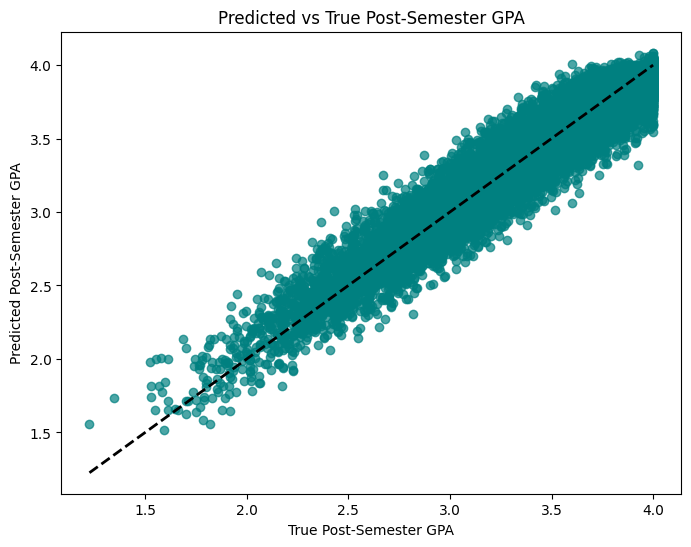

In [18]:
# Plot predictions vs true values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7, color='teal')
plt.xlabel('True Post-Semester GPA')
plt.ylabel('Predicted Post-Semester GPA')
plt.title('Predicted vs True Post-Semester GPA')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  
plt.show()

In [19]:
import mlflow

# Адрес локального сервера
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_registry_uri("http://127.0.0.1:5000")  

In [20]:
# название тестового эксперимента, запуска (run) внутри него, имени, под которым модель будет регистрироваться
EXPERIMENT_NAME = "student_gpa_research"
RUN_NAME = "baseline_model"
REGISTRY_MODEL_NAME = "student_gpa_model_rf"

In [21]:
# Обязательно логируем сигнатуру модели и пример входных данных. Подготовим их
from mlflow.models import infer_signature

signature =  infer_signature(model_input = X_train.head(5))
input_example = X_train.head(5)

/home/mainuser/my_proj/.venv_my_proj/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [22]:
# Будем логировать requirements и артефакт - текстовый файл
req_file = 'requirements.txt'
art = 'comment.txt'

In [23]:
# Параметры, котороые будут залогированы, можем задавать вручную или полностью взять из модели
#params_dict = {'n_estimators': 10, 'max_depth': 10}
params_dict = pipeline.get_params()

In [24]:
client = mlflow.tracking.MlflowClient()

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    print(f"Создан новый эксперимент с ID: {experiment_id}")
else:
    experiment_id = experiment.experiment_id
    if experiment.lifecycle_stage == "deleted":
        client.restore_experiment(experiment_id)
    print(f"Используется эксперимент с ID: {experiment_id}")

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(params_dict)

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

Используется эксперимент с ID: 1


2026/09/29 10:45:55 INFO mlflow.tracking._tracking_service.client: 🏃 View run baseline_model at: http://127.0.0.1:5000/#/experiments/1/runs/d81d7ec8e11b4eb092192f8969f3ba62.
2026/09/29 10:45:55 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Удаление ненужных ранов

In [25]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
#mlflow.delete_experiment(experiment_id)

In [26]:
mlflow.search_runs(
    #experiment_ids=[experiment_id],
    experiment_names=[EXPERIMENT_NAME],
    # filter_string='status = "FAILED"'
    #filter_string='metrics.mae > 1'
)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.mae,metrics.mape,metrics.mse,metrics.training_r2_score,...,params.model__warm_start,params.model__min_samples_leaf,tags.mlflow.log-model.history,tags.mlflow.user,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.source.git.commit,tags.estimator_name,tags.estimator_class
0,d81d7ec8e11b4eb092192f8969f3ba62,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/d8...,2026-09-29 07:45:54.813000+00:00,2026-09-29 07:45:55.764000+00:00,0.112528,0.035153,0.020554,NaN,...,None,None,"[{""run_id"": ""d81d7ec8e11b4eb092192f8969f3ba62""...",mainuser,LOCAL,baseline_model,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,None,None,None
1,d3b588c6b3d64c65a4a43962f2d9ef19,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/d3...,2026-09-29 07:33:30.439000+00:00,2026-09-29 07:33:30.562000+00:00,0.112518,0.035141,0.020568,NaN,...,None,None,"[{""run_id"": ""d3b588c6b3d64c65a4a43962f2d9ef19""...",mainuser,LOCAL,fe_sklearn,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,4c3a12c62096ead17fbad42ec6250fa81091b0b0,None,None
2,7d846d6f4420445ca18206001f6ee0ad,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/7d...,2026-09-29 07:15:12.596000+00:00,2026-09-29 07:15:12.742000+00:00,0.130269,0.040841,0.028530,NaN,...,False,1,"[{""run_id"": ""7d846d6f4420445ca18206001f6ee0ad""...",mainuser,LOCAL,register_at_run,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,4c3a12c62096ead17fbad42ec6250fa81091b0b0,None,None
3,090c293029494ef58346ee5f06e5c859,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/09...,2026-09-29 07:13:03.240000+00:00,2026-09-29 07:13:03.279000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,mainuser,LOCAL,no_model,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,4c3a12c62096ead17fbad42ec6250fa81091b0b0,None,None
4,ae6ad4b12d464cb9a418cb356358aadf,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/ae...,2026-09-29 07:12:38.258000+00:00,2026-09-29 07:12:38.391000+00:00,0.130269,0.040841,0.028530,NaN,...,False,1,"[{""run_id"": ""ae6ad4b12d464cb9a418cb356358aadf""...",mainuser,LOCAL,smaller_model,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,4c3a12c62096ead17fbad42ec6250fa81091b0b0,None,None
5,840233f6000342399f08098d8d792810,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/84...,2026-09-29 07:10:12.773000+00:00,2026-09-29 07:10:49.008000+00:00,NaN,NaN,NaN,0.929723,...,None,None,"[{""run_id"": ""840233f6000342399f08098d8d792810""...",mainuser,LOCAL,auto,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,4c3a12c62096ead17fbad42ec6250fa81091b0b0,Pipeline,sklearn.pipeline.Pipeline
6,8592fd6d67264b7992f8132ef1dd71d6,1,FINISHED,/home/mainuser/my_proj/mlflow/mlartifacts/1/85...,2026-09-29 07:01:36.061000+00:00,2026-09-29 07:01:36.168000+00:00,0.112528,0.035153,0.020554,NaN,...,None,None,"[{""run_id"": ""8592fd6d67264b7992f8132ef1dd71d6""...",mainuser,LOCAL,baseline_model,/home/mainuser/my_proj/.venv_my_proj/lib/pytho...,4c3a12c62096ead17fbad42ec6250fa81091b0b0,None,None


In [138]:
# mlflow.delete_run('edfec6ad63a54c8791c3f2f9c3dbb50f')

# Автологирование

In [28]:
mlflow.sklearn.autolog()

with mlflow.start_run(run_name='auto', experiment_id=experiment_id) as run:
    pipeline.fit(X_train, y_train)

2026/09/29 10:45:55 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 0.24.1 <= scikit-learn <= 1.5.1, but the installed version is 1.7.2. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2026/09/29 10:46:29 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/mainuser/my_proj/.venv_my_proj/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever the

Learning rate set to 0.07259
0:	learn: 0.4671741	total: 1.72ms	remaining: 1.72s
1:	learn: 0.4402446	total: 3.15ms	remaining: 1.57s
2:	learn: 0.4153623	total: 6.49ms	remaining: 2.16s
3:	learn: 0.3919939	total: 10.1ms	remaining: 2.51s
4:	learn: 0.3706766	total: 12.3ms	remaining: 2.45s
5:	learn: 0.3510969	total: 15ms	remaining: 2.49s
6:	learn: 0.3336505	total: 17.5ms	remaining: 2.49s
7:	learn: 0.3173750	total: 19.9ms	remaining: 2.47s
8:	learn: 0.3025373	total: 21.8ms	remaining: 2.4s
9:	learn: 0.2889980	total: 22.9ms	remaining: 2.27s
10:	learn: 0.2767623	total: 24.1ms	remaining: 2.16s
11:	learn: 0.2656584	total: 25.2ms	remaining: 2.07s
12:	learn: 0.2557876	total: 26.4ms	remaining: 2.01s
13:	learn: 0.2463335	total: 27.5ms	remaining: 1.94s
14:	learn: 0.2381940	total: 28.6ms	remaining: 1.88s
15:	learn: 0.2305183	total: 29.7ms	remaining: 1.83s
16:	learn: 0.2234734	total: 30.8ms	remaining: 1.78s
17:	learn: 0.2172275	total: 31.9ms	remaining: 1.74s
18:	learn: 0.2116569	total: 33.8ms	remaining: 1.

2026/09/29 10:46:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/mainuser/my_proj/.venv_my_proj/lib/python3.10/site-packages/mlflow/types/utils.py:407: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/09/29 10:46:32 INFO mlflow.tracking._tracking_service.client: 🏃 View run auto at: http://127.0.0.1:5000/#/experiments/1/runs/a13a5

In [29]:
# Отключаем автологирование
mlflow.sklearn.autolog(disable=True)

# Model #2
Обучим вторую "маленькую" модель

In [30]:
regressor2 = RandomForestRegressor(n_estimators=10, max_depth=6)

In [31]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                           ('model', regressor2)])

pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [32]:
predictions = pipeline.predict(X_test) 
metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.13020115033040028,
 'mape': 0.04079911472119932,
 'mse': 0.02848146324469029}

In [33]:
RUN_NAME = 'smaller_model'

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(pipeline.get_params())

run = mlflow.get_run(run_id) 

2026/09/29 10:46:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run smaller_model at: http://127.0.0.1:5000/#/experiments/1/runs/d13dac8f03f4412e830205ba81f31066.
2026/09/29 10:46:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [34]:
# No model
# Логировать можно только артефакты, без модели. Например, залогироавть графики после этапа EDA

RUN_NAME = 'no_model'
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    run_id = run.info.run_id 
    mlflow.log_artifact(art)


run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 10:46:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run no_model at: http://127.0.0.1:5000/#/experiments/1/runs/d3cf1dc427c34c779812dbaf23e132cb.
2026/09/29 10:46:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [35]:
run_id = 'ae6ad4b12d464cb9a418cb356358aadf' # Указываем run id
mlflow.register_model(f"runs:/{run_id}/models", REGISTRY_MODEL_NAME)

Registered model 'student_gpa_model_rf' already exists. Creating a new version of this model...
2026/09/29 10:46:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: student_gpa_model_rf, version 3
Created version '3' of model 'student_gpa_model_rf'.


<ModelVersion: aliases=[], creation_timestamp=1790667993663, current_stage='None', description='', last_updated_timestamp=1790667993663, name='student_gpa_model_rf', run_id='ae6ad4b12d464cb9a418cb356358aadf', run_link='', source='/home/mainuser/my_proj/mlflow/mlartifacts/1/ae6ad4b12d464cb9a418cb356358aadf/artifacts/models', status='READY', status_message='', tags={}, user_id='', version='3'>

In [36]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name='register_at_run', experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file,
                             registered_model_name = REGISTRY_MODEL_NAME # Указываем для какой модели регистрируем
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(pipeline.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

Registered model 'student_gpa_model_rf' already exists. Creating a new version of this model...
2026/09/29 10:46:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: student_gpa_model_rf, version 4
Created version '4' of model 'student_gpa_model_rf'.
2026/09/29 10:46:33 INFO mlflow.tracking._tracking_service.client: 🏃 View run register_at_run at: http://127.0.0.1:5000/#/experiments/1/runs/edfec6ad63a54c8791c3f2f9c3dbb50f.
2026/09/29 10:46:33 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


In [37]:
# Можно найти зарегистрированные модели
model_reg = mlflow.search_registered_models()
print(model_reg[0])

<RegisteredModel: aliases={}, creation_timestamp=1790666065640, description='', last_updated_timestamp=1790667993769, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1790667993769, current_stage='None', description='', last_updated_timestamp=1790667993769, name='student_gpa_model_rf', run_id='edfec6ad63a54c8791c3f2f9c3dbb50f', run_link='', source='/home/mainuser/my_proj/mlflow/mlartifacts/1/edfec6ad63a54c8791c3f2f9c3dbb50f/artifacts/models', status='READY', status_message='', tags={}, user_id='', version='4'>], name='student_gpa_model_rf', tags={}>


In [38]:
model_name = REGISTRY_MODEL_NAME
model_version = 1

model_loaded = mlflow.sklearn.load_model(model_uri=f"models:/{model_name}/{model_version}")

In [39]:
model_loaded.predict(X_test.iloc[0:1])

array([2.34739505])

In [40]:
y_test.iloc[0]

2.582

# Feature engineering

## Sklearn

In [41]:
from sklearn.preprocessing import QuantileTransformer, SplineTransformer, PolynomialFeatures, MinMaxScaler, KBinsDiscretizer

In [42]:
X_train_sklearn = X_train.copy()

#### PolynomialFeatures
Создает полином степени `degree` из указанных признаков

In [43]:
pf = PolynomialFeatures(degree=2)
X_train_sklearn

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level,High_Risk_Student
27434,STEM,Senior,3.074,3.040000,Ideation,Beginner,1,False,20.600000,2,Actively_Encouraged,2,88.699997,Medium,False
13400,Medical,Freshman,3.389,0.300000,Direct_Answer_Generation,Intermediate,3,False,7.560000,1,Allowed_With_Citation,2,84.699997,Low,False
883,STEM,Senior,3.822,32.869999,Copywriting/Drafting,Beginner,1,False,8.000000,6,Allowed_With_Citation,6,75.540001,High,False
7303,Medical,Sophomore,1.534,4.510000,Debugging/Troubleshooting,Beginner,2,False,18.030001,2,Allowed_With_Citation,7,84.110001,Medium,False
45124,Business,Freshman,3.809,3.740000,Ideation,Advanced,3,False,3.390000,2,Allowed_With_Citation,2,98.250000,Low,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,Medical,Sophomore,3.589,2.190000,Direct_Answer_Generation,Beginner,1,True,10.950000,4,Strict_Ban,4,63.340000,Low,False
44732,STEM,Sophomore,3.793,2.360000,Debugging/Troubleshooting,Beginner,2,False,18.420000,3,Allowed_With_Citation,9,97.349998,Low,False
38158,Humanities,Sophomore,3.804,8.220000,Copywriting/Drafting,Beginner,1,True,13.260000,4,Allowed_With_Citation,5,86.000000,High,False
860,Arts,Junior,2.899,16.620001,Copywriting/Drafting,Beginner,1,False,6.940000,7,Actively_Encouraged,9,84.800003,Medium,False


In [44]:
pf.fit_transform(X_train_sklearn[['Weekly_GenAI_Hours','Pre_Semester_GPA', 'Traditional_Study_Hours']])

array([[1.0000000e+00, 3.0400000e+00, 3.0739999e+00, ..., 9.4494753e+00,
        6.3324398e+01, 4.2436002e+02],
       [1.0000000e+00, 3.0000001e-01, 3.3889999e+00, ..., 1.1485321e+01,
        2.5620840e+01, 5.7153599e+01],
       [1.0000000e+00, 3.2869999e+01, 3.8220000e+00, ..., 1.4607684e+01,
        3.0576000e+01, 6.4000000e+01],
       ...,
       [1.0000000e+00, 8.2200003e+00, 3.8039999e+00, ..., 1.4470415e+01,
        5.0441040e+01, 1.7582761e+02],
       [1.0000000e+00, 1.6620001e+01, 2.8989999e+00, ..., 8.4042006e+00,
        2.0119061e+01, 4.8163601e+01],
       [1.0000000e+00, 1.1000000e-01, 2.8369999e+00, ..., 8.0485687e+00,
        1.0695490e+01, 1.4212900e+01]], dtype=float32)

#### SplineTransformer
Cоздаёт новую матрицу признаков, состоящую из сплайнов порядка degree. Количество сгенерированных сплайнов равно `n_splines=n_knots + degree - 1` для каждого признака, где

`n_knots` определяет количество узлов (точек, в которых сопрягаются сплайны) для каждого признака. 

`degree` определяет порядок полинома, используемого для построения сплайнов. 

In [45]:
sp = SplineTransformer(n_knots=3, degree=3)

In [46]:
sp.fit_transform(X_train_sklearn[['Pre_Semester_GPA']])

array([[0.0000000e+00, 4.7154106e-02, 5.6893098e-01, 3.7715885e-01,
        6.7560514e-03],
       [0.0000000e+00, 1.3500671e-02, 4.3611255e-01, 5.1995492e-01,
        3.0431852e-02],
       [0.0000000e+00, 3.2586721e-04, 2.3602927e-01, 6.5200818e-01,
        1.1163668e-01],
       ...,
       [0.0000000e+00, 4.3642416e-04, 2.4377289e-01, 6.4897799e-01,
        1.0681269e-01],
       [0.0000000e+00, 7.9340808e-02, 6.2389040e-01, 2.9501382e-01,
        1.7549681e-03],
       [0.0000000e+00, 9.3540616e-02, 6.3868082e-01, 2.6688328e-01,
        8.9527067e-04]], dtype=float32)

#### QuantileTransformer
Этот метод преобразует признаки, чтобы они распределялись равномерно или нормально — так данные меньше подвергаются влиянию выбросов. Преобразование применяется к каждому признаку независимо. Идея метода такова: оценить функцию распределения признака, чтобы преобразовать исходные значения в равномерное или нормальное распределение. 

`output_distribution='uniform'` или
`output_distribution='normal'` соответственно


Пример использования: если у вас есть данные о доходах с широким диапазоном значений, квантильное преобразование сделает их более сопоставимыми и устойчивыми к выбросам.

In [47]:
qt = QuantileTransformer()

In [48]:
qt.fit_transform(X_train_sklearn[['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Pre_Semester_GPA']])

array([[0.3043043 , 0.962363  , 0.39189184],
       [0.03703704, 0.25025025, 0.6411411 ],
       [0.97590613, 0.27767697, 0.95433974],
       ...,
       [0.6256256 , 0.6516517 , 0.9456063 ],
       [0.8598599 , 0.2122122 , 0.28278273],
       [0.01301301, 0.08208209, 0.24724725]], dtype=float32)

### Объединяем в ColumnTransformer и создаем Pipeline 

In [49]:
pf = PolynomialFeatures(degree=2)
qt = QuantileTransformer()
sp = SplineTransformer(n_knots=3, degree=3)

In [50]:
# Значения преобразованных признаков нужно отскейлить, поэтому создаем pipeline из двух шагов - преобразование и скейлинг
pf_pipeline = Pipeline(steps=[
    ('poly', pf),
    ('scale', StandardScaler())
])

In [51]:
preprocessor_sklearn = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
        ('quantile', qt, num_features),
        ('poly', pf_pipeline, ['Weekly_GenAI_Hours','Pre_Semester_GPA', 'Traditional_Study_Hours']),
        ('spline', sp, ['Pre_Semester_GPA'])
    ],
    remainder='drop',
    ) # Удаляем столбцы, которые не затронуты преобразования

In [53]:
X_train_sklearn_raw = preprocessor_sklearn.fit_transform(X_train_sklearn)
X_train_sklearn = pd.DataFrame(X_train_sklearn_raw, columns=preprocessor_sklearn.get_feature_names_out())

In [54]:
# Удобно использовать для отображения всех строк\столбцов в DataFrame
with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_sklearn)

,num__Pre_Semester_GPA,num__Weekly_GenAI_Hours,num__Tool_Diversity,num__Traditional_Study_Hours,num__Perceived_AI_Dependency,num__Anxiety_Level_During_Exams,num__Skill_Retention_Score,cat__Major_Category,cat__Year_of_Study,cat__Primary_Use_Case,cat__Prompt_Engineering_Skill,cat__Institutional_Policy,cat__Burnout_Risk_Level,quantile__Pre_Semester_GPA,quantile__Weekly_GenAI_Hours,quantile__Tool_Diversity,quantile__Traditional_Study_Hours,quantile__Perceived_AI_Dependency,quantile__Anxiety_Level_During_Exams,quantile__Skill_Retention_Score,poly__1,poly__Weekly_GenAI_Hours,poly__Pre_Semester_GPA,poly__Traditional_Study_Hours,poly__Weekly_GenAI_Hours^2,poly__Weekly_GenAI_Hours Pre_Semester_GPA,poly__Weekly_GenAI_Hours Traditional_Study_Hours,poly__Pre_Semester_GPA^2,poly__Pre_Semester_GPA Traditional_Study_Hours,poly__Traditional_Study_Hours^2,spline__Pre_Semester_GPA_sp_0,spline__Pre_Semester_GPA_sp_1,spline__Pre_Semester_GPA_sp_2,spline__Pre_Semester_GPA_sp_3,spline__Pre_Semester_GPA_sp_4
0,-0.151400,-0.651688,-1.514222,1.821908,-0.825604,-1.058724,0.971584,4.0,3.0,3.0,1.0,0.0,2.0,0.404404,0.303303,0.000000,0.964629,0.232733,0.164665,0.829496,0.0,-0.651688,-0.151400,1.821908,-0.487728,-0.645705,-0.260877,-0.235655,1.629333,2.199955,0.0,0.047154,0.568931,0.377159,0.006756
1,0.506002,-0.982720,0.166578,-0.704581,-1.374971,-1.058724,0.670496,3.0,0.0,2.0,2.0,1.0,1.0,0.650651,0.034535,0.571572,0.253253,0.000000,0.164665,0.746246,0.0,-0.982720,0.506002,-0.704581,-0.521956,-0.958475,-0.886599,0.468978,-0.555854,-0.766134,0.0,0.013501,0.436113,0.519955,0.030432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37498,-0.516623,0.988975,-1.514222,-0.824705,1.921232,2.201430,0.678023,0.0,2.0,0.0,1.0,0.0,2.0,0.286787,0.851893,0.000000,0.217260,0.951451,0.972973,0.748271,0.0,0.988975,-0.516623,-0.824705,0.510824,0.812810,0.285668,-0.597438,-0.874721,-0.838750,0.0,0.079341,0.623890,0.295014,0.001755
37499,-0.646016,-1.005675,-1.514222,-1.438890,-0.276236,-1.058724,-0.207175,4.0,0.0,1.0,2.0,0.0,2.0,0.254254,0.012513,0.000000,0.084084,0.425926,0.164665,0.416416,0.0,-1.005675,-0.646016,-1.438890,-0.522247,-0.984938,-0.905812,-0.720527,-1.420883,-1.112985,0.0,0.093541,0.638681,0.266883,0.000895


### Создаем пайплайн с препроцессингом и моделью

In [55]:
pipeline_sklearn = Pipeline(steps=[
    ('transform', preprocessor_sklearn),
    ('model', regressor)
])

model_sklearn = pipeline_sklearn.fit(X_train, y_train)

Learning rate set to 0.07259
0:	learn: 0.4670328	total: 3ms	remaining: 3s
1:	learn: 0.4391047	total: 6.42ms	remaining: 3.21s
2:	learn: 0.4135490	total: 8.49ms	remaining: 2.82s
3:	learn: 0.3900525	total: 10.6ms	remaining: 2.65s
4:	learn: 0.3685220	total: 13.6ms	remaining: 2.7s
5:	learn: 0.3487650	total: 15.5ms	remaining: 2.56s
6:	learn: 0.3305060	total: 17.5ms	remaining: 2.49s
7:	learn: 0.3141692	total: 19.6ms	remaining: 2.43s
8:	learn: 0.2994777	total: 21.6ms	remaining: 2.37s
9:	learn: 0.2857915	total: 23.4ms	remaining: 2.31s
10:	learn: 0.2735464	total: 25.3ms	remaining: 2.28s
11:	learn: 0.2622067	total: 27.3ms	remaining: 2.24s
12:	learn: 0.2519827	total: 29.4ms	remaining: 2.23s
13:	learn: 0.2427046	total: 31.3ms	remaining: 2.2s
14:	learn: 0.2344860	total: 33.2ms	remaining: 2.18s
15:	learn: 0.2270373	total: 35.1ms	remaining: 2.16s
16:	learn: 0.2205337	total: 37ms	remaining: 2.14s
17:	learn: 0.2143460	total: 38.8ms	remaining: 2.12s
18:	learn: 0.2089844	total: 40.6ms	remaining: 2.09s
19:

In [56]:
model_sklearn

,steps,"[('transform', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [57]:
predictions = model_sklearn.predict(X_test) 
metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

{'mae': 0.11251787176952527,
 'mape': 0.035141101086246004,
 'mse': 0.020568019376462306}

In [58]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'fe_sklearn'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(model_sklearn, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 10:46:37 INFO mlflow.tracking._tracking_service.client: 🏃 View run fe_sklearn at: http://127.0.0.1:5000/#/experiments/1/runs/5b0f285b45f44c309ec6d8d1f195ab01.
2026/09/29 10:46:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


## Autofeat

In [59]:
from autofeat import AutoFeatRegressor
transformations = ["1/", "exp", "log", "abs", "sqrt", "^2", "^3", "1+", "1-", "sin", "cos", "exp-", "2^"] 

In [66]:
num_features

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Skill_Retention_Score']

In [72]:
cat_features

['Major_Category',
 'Year_of_Study',
 'Primary_Use_Case',
 'Prompt_Engineering_Skill',
 'Institutional_Policy',
 'Burnout_Risk_Level']

In [76]:
X_train

,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Skill_Retention_Score,Burnout_Risk_Level,High_Risk_Student
27434,STEM,Senior,3.074,3.040000,Ideation,Beginner,1,False,20.600000,2,Actively_Encouraged,2,88.699997,Medium,False
13400,Medical,Freshman,3.389,0.300000,Direct_Answer_Generation,Intermediate,3,False,7.560000,1,Allowed_With_Citation,2,84.699997,Low,False
883,STEM,Senior,3.822,32.869999,Copywriting/Drafting,Beginner,1,False,8.000000,6,Allowed_With_Citation,6,75.540001,High,False
7303,Medical,Sophomore,1.534,4.510000,Debugging/Troubleshooting,Beginner,2,False,18.030001,2,Allowed_With_Citation,7,84.110001,Medium,False
45124,Business,Freshman,3.809,3.740000,Ideation,Advanced,3,False,3.390000,2,Allowed_With_Citation,2,98.250000,Low,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,Medical,Sophomore,3.589,2.190000,Direct_Answer_Generation,Beginner,1,True,10.950000,4,Strict_Ban,4,63.340000,Low,False
44732,STEM,Sophomore,3.793,2.360000,Debugging/Troubleshooting,Beginner,2,False,18.420000,3,Allowed_With_Citation,9,97.349998,Low,False
38158,Humanities,Sophomore,3.804,8.220000,Copywriting/Drafting,Beginner,1,True,13.260000,4,Allowed_With_Citation,5,86.000000,High,False
860,Arts,Junior,2.899,16.620001,Copywriting/Drafting,Beginner,1,False,6.940000,7,Actively_Encouraged,9,84.800003,Medium,False


In [75]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 27434 to 15795
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Major_Category              37500 non-null  category
 1   Year_of_Study               37500 non-null  category
 2   Pre_Semester_GPA            37500 non-null  float32 
 3   Weekly_GenAI_Hours          37500 non-null  float32 
 4   Primary_Use_Case            37500 non-null  category
 5   Prompt_Engineering_Skill    37500 non-null  category
 6   Tool_Diversity              37500 non-null  int8    
 7   Paid_Subscription           37500 non-null  bool    
 8   Traditional_Study_Hours     37500 non-null  float32 
 9   Perceived_AI_Dependency     37500 non-null  int8    
 10  Institutional_Policy        37500 non-null  category
 11  Anxiety_Level_During_Exams  37500 non-null  int8    
 12  Skill_Retention_Score       37500 non-null  float32 
 13  Burnout_Risk_Leve

In [73]:
afreg = AutoFeatRegressor(verbose=1, feateng_steps=2, max_gb=8, transformations=["log", "sqrt"])
X_train_arf = afreg.fit_transform(X_train,y_train)
X_train_arf

ValueError: Cannot cast object dtype to float64

In [ ]:
# Создаем обертку, в которой добавляем метод get_feature_names_out() для получения названий признаков
class AutoFeatWrapper():
    def __init__(self, feateng_cols, feateng_steps=1, max_gb=16, transformations=["1/", "exp", "log"], n_jobs=-1, verbose=1):
        self.feateng_cols = feateng_cols
        self.feateng_steps = feateng_steps
        self.max_gb = max_gb
        self.transformations = transformations
        self.n_jobs = n_jobs
        self.afreg = AutoFeatRegressor(feateng_cols=self.feateng_cols,
                                     feateng_steps=self.feateng_steps,
                                     max_gb=self.max_gb,
                                     transformations=self.transformations,
                                     n_jobs=self.n_jobs)
        
    def fit(self, X, y=None):
        self.afreg.fit(X, y)
        return self
    
    def transform(self, X):
        return self.afreg.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        # Преобразуем данные и возвращаем имена фичей из DataFrame
        transformed_X = self.afreg.transform(pd.DataFrame(np.zeros((1, len(self.feateng_cols))), columns=self.feateng_cols))
        return transformed_X.columns.tolist()

In [ ]:
afreg_pipeline = Pipeline(steps=[
    ('autofeat', AutoFeatWrapper( feateng_steps=2, max_gb=16, transformations=["log", "sqrt"],feateng_cols=num_features)),
    ('scaler', StandardScaler()),
])

In [ ]:
preprocessor_afr = ColumnTransformer(
    transformers=[
        ('num', s_scaler, num_features),  # преобразования для числовых признаков
        ('cat', l_encoder, cat_features), # преобразования для категориальных признаков
        ('afr', afreg_pipeline, num_features), # преобразования autofeat
    ],
    remainder='drop', # Удаляем столбцы, которые не затронуты преобразованиями
    ) 

In [ ]:
X_train_afr_raw =  preprocessor_afr.fit_transform(X_train,y_train)
X_train_afr = pd.DataFrame(X_train_afr_raw, columns=preprocessor_afr.get_feature_names_out())

In [ ]:
with pd.option_context('display.max_rows', 5, 'display.max_columns', None):
    display (X_train_afr)


In [ ]:
pipeline_afr = Pipeline(steps=[('preprocessor', preprocessor_afr), 
                               ('model', regressor)])

pipeline_afr.fit(X_train, y_train)


In [ ]:
predictions = pipeline_afr.predict(X_test) 

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions)
metrics["mse"] = mean_squared_error(y_test, predictions)

metrics

In [ ]:

experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name='autofeat', experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(pipeline_afr, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(pipeline_afr.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

# FEATURE SELECTION
## RFE
### Используем autofeat признаки
Поскольку autofeat дает разные совокупности сгенерированных признаков, мы можем добавить выбор информативных только как шаг пайплайна 

In [139]:
from sklearn.feature_selection import RFE
X_train_sklearn

,num__Pre_Semester_GPA,num__Weekly_GenAI_Hours,num__Tool_Diversity,num__Traditional_Study_Hours,num__Perceived_AI_Dependency,num__Anxiety_Level_During_Exams,num__Skill_Retention_Score,cat__Major_Category,cat__Year_of_Study,cat__Primary_Use_Case,...,poly__Weekly_GenAI_Hours Pre_Semester_GPA,poly__Weekly_GenAI_Hours Traditional_Study_Hours,poly__Pre_Semester_GPA^2,poly__Pre_Semester_GPA Traditional_Study_Hours,poly__Traditional_Study_Hours^2,spline__Pre_Semester_GPA_sp_0,spline__Pre_Semester_GPA_sp_1,spline__Pre_Semester_GPA_sp_2,spline__Pre_Semester_GPA_sp_3,spline__Pre_Semester_GPA_sp_4
0,-0.151400,-0.651688,-1.514222,1.821908,-0.825604,-1.058724,0.971584,4.0,3.0,3.0,...,-0.645705,-0.260877,-0.235655,1.629333,2.199955,0.000000,0.047154,0.568931,0.377159,0.006756
1,0.506002,-0.982720,0.166578,-0.704581,-1.374971,-1.058724,0.670496,3.0,0.0,2.0,...,-0.958475,-0.886599,0.468978,-0.555854,-0.766134,0.000000,0.013501,0.436113,0.519955,0.030432
2,1.409669,2.952213,-1.514222,-0.619331,1.371865,0.804221,-0.018995,4.0,3.0,0.0,...,3.721385,1.816043,1.549669,-0.268667,-0.710832,0.000000,0.000326,0.236029,0.652008,0.111637
3,-3.365364,-0.474090,-0.673822,1.323973,-0.825604,1.269957,0.626086,3.0,4.0,1.0,...,-0.736837,-0.067101,-2.691783,-0.437785,1.398034,0.070487,0.612231,0.314696,0.002585,0.000000
4,1.382538,-0.567118,0.166578,-1.512515,-0.825604,-1.058724,1.690431,1.0,0.0,3.0,...,-0.461657,-0.778670,1.515333,-1.292391,-1.134962,0.000000,0.000404,0.241612,0.649846,0.108138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37495,0.923400,-0.754380,-1.514222,-0.047771,0.273131,-0.127252,-0.937312,3.0,4.0,2.0,...,-0.701476,-0.661501,0.952014,0.236924,-0.259283,0.000000,0.004090,0.341911,0.594495,0.059504
37496,1.349146,-0.733842,-0.673822,1.399535,-0.276236,2.201430,1.622686,4.0,4.0,1.0,...,-0.660482,-0.459437,1.473235,2.008527,1.512859,0.000000,0.000515,0.248553,0.646998,0.103934
37497,1.372103,-0.025868,-1.514222,0.399790,0.273131,0.338485,0.768350,2.0,4.0,0.0,...,0.177655,0.219883,1.502158,0.882652,0.192449,0.000000,0.000436,0.243773,0.648978,0.106813
37498,-0.516623,0.988975,-1.514222,-0.824705,1.921232,2.201430,0.678023,0.0,2.0,0.0,...,0.812810,0.285668,-0.597438,-0.874721,-0.838750,0.000000,0.079341,0.623890,0.295014,0.001755


In [140]:

rfe_selector = RFE(estimator=regressor, n_features_to_select=12, step = 0.2) #drop 20% of features each iteration
X_train_rfe = rfe_selector.fit_transform(X_train_sklearn,y_train)

Learning rate set to 0.07259
0:	learn: 0.4670328	total: 6.5ms	remaining: 6.5s
1:	learn: 0.4391047	total: 12.8ms	remaining: 6.37s
2:	learn: 0.4135490	total: 15ms	remaining: 5s
3:	learn: 0.3900525	total: 18.1ms	remaining: 4.52s
4:	learn: 0.3685220	total: 20.4ms	remaining: 4.07s
5:	learn: 0.3487650	total: 23.1ms	remaining: 3.83s
6:	learn: 0.3305060	total: 25.2ms	remaining: 3.58s
7:	learn: 0.3141692	total: 27.4ms	remaining: 3.4s
8:	learn: 0.2994777	total: 29.4ms	remaining: 3.23s
9:	learn: 0.2857915	total: 36.2ms	remaining: 3.58s
10:	learn: 0.2735464	total: 38.7ms	remaining: 3.48s
11:	learn: 0.2622067	total: 41.9ms	remaining: 3.45s
12:	learn: 0.2519827	total: 44.3ms	remaining: 3.36s
13:	learn: 0.2427046	total: 48.8ms	remaining: 3.44s
14:	learn: 0.2344860	total: 51.2ms	remaining: 3.36s
15:	learn: 0.2270373	total: 54.5ms	remaining: 3.35s
16:	learn: 0.2205337	total: 56.8ms	remaining: 3.29s
17:	learn: 0.2143460	total: 58.9ms	remaining: 3.21s
18:	learn: 0.2089844	total: 60.9ms	remaining: 3.15s
1

In [141]:
X_train_sklearn_rfe = pd.DataFrame(X_train_rfe, columns=rfe_selector.get_feature_names_out())
X_train_sklearn_rfe

,num__Pre_Semester_GPA,num__Skill_Retention_Score,cat__Year_of_Study,cat__Primary_Use_Case,quantile__Pre_Semester_GPA,poly__Pre_Semester_GPA,poly__Pre_Semester_GPA^2,poly__Pre_Semester_GPA Traditional_Study_Hours,spline__Pre_Semester_GPA_sp_1,spline__Pre_Semester_GPA_sp_2,spline__Pre_Semester_GPA_sp_3,spline__Pre_Semester_GPA_sp_4
0,-0.151400,0.971584,3.0,3.0,0.404404,-0.151400,-0.235655,1.629333,0.047154,0.568931,0.377159,0.006756
1,0.506002,0.670496,0.0,2.0,0.650651,0.506002,0.468978,-0.555854,0.013501,0.436113,0.519955,0.030432
2,1.409669,-0.018995,3.0,0.0,0.955956,1.409669,1.549669,-0.268667,0.000326,0.236029,0.652008,0.111637
3,-3.365364,0.626086,4.0,1.0,0.000753,-3.365364,-2.691783,-0.437785,0.612231,0.314696,0.002585,0.000000
4,1.382538,1.690431,0.0,3.0,0.950284,1.382538,1.515333,-1.292391,0.000404,0.241612,0.649846,0.108138
...,...,...,...,...,...,...,...,...,...,...,...,...
37495,0.923400,-0.937312,4.0,2.0,0.808809,0.923400,0.952014,0.236924,0.004090,0.341911,0.594495,0.059504
37496,1.349146,1.622686,4.0,1.0,0.941942,1.349146,1.473235,2.008527,0.000515,0.248553,0.646998,0.103934
37497,1.372103,0.768350,4.0,0.0,0.947948,1.372103,1.502158,0.882652,0.000436,0.243773,0.648978,0.106813
37498,-0.516623,0.678023,2.0,0.0,0.286787,-0.516623,-0.597438,-0.874721,0.079341,0.623890,0.295014,0.001755


In [143]:
rfe_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', RFE(estimator=regressor, n_features_to_select=12, step = 0.2)),
    ('model', regressor)
])

rfe_pipeline.fit(X_train, y_train)

Learning rate set to 0.07259
0:	learn: 0.4670328	total: 2.65ms	remaining: 2.65s
1:	learn: 0.4391047	total: 4.79ms	remaining: 2.39s
2:	learn: 0.4135490	total: 8.67ms	remaining: 2.88s
3:	learn: 0.3900525	total: 11.1ms	remaining: 2.77s
4:	learn: 0.3685220	total: 14.8ms	remaining: 2.95s
5:	learn: 0.3487650	total: 17.5ms	remaining: 2.9s
6:	learn: 0.3305060	total: 19.7ms	remaining: 2.79s
7:	learn: 0.3141692	total: 21.7ms	remaining: 2.7s
8:	learn: 0.2994777	total: 26.6ms	remaining: 2.93s
9:	learn: 0.2857915	total: 29ms	remaining: 2.87s
10:	learn: 0.2735464	total: 32.9ms	remaining: 2.95s
11:	learn: 0.2622067	total: 36.1ms	remaining: 2.98s
12:	learn: 0.2519827	total: 38.4ms	remaining: 2.92s
13:	learn: 0.2427046	total: 40.6ms	remaining: 2.86s
14:	learn: 0.2344860	total: 42.9ms	remaining: 2.81s
15:	learn: 0.2270373	total: 48ms	remaining: 2.95s
16:	learn: 0.2205337	total: 51.2ms	remaining: 2.96s
17:	learn: 0.2143460	total: 54.1ms	remaining: 2.95s
18:	learn: 0.2089844	total: 56.3ms	remaining: 2.91s

,steps,"[('preprocessor', ...), ('rfe_extractor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [144]:
predictions_rfe = rfe_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_rfe)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_rfe)
metrics["mse"] = mean_squared_error(y_test, predictions_rfe)

metrics

{'mae': 0.12064330711308198,
 'mape': 0.03775643077048681,
 'mse': 0.024098243595988608}

In [145]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(rfe_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 12:50:59 INFO mlflow.tracking._tracking_service.client: 🏃 View run rfe_feature_selection at: http://127.0.0.1:5000/#/experiments/1/runs/35114a4fc06e45e482f9e7c9aa0ed11b.
2026/09/29 12:50:59 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


### Используем sklearn признаки
Тут мы можем отобрать признаки один раз на обучении, а далее в качестве шага пайплайна использовать написанный класс ColumnExtractor для выбора нуных столбцов

In [ ]:

rfe_skl_selector = RFE(estimator=regressor, n_features_to_select=12, step = 0.2) #drop 20% of features each iteration
X_train_skl_rfe = rfe_skl_selector.fit_transform(X_train_sklearn,y_train)

In [ ]:
X_train_skl_rfe = pd.DataFrame(X_train_skl_rfe, columns=rfe_skl_selector.get_feature_names_out())
X_train_skl_rfe

In [ ]:
rfe_cols = X_train_skl_rfe.columns.tolist()
rfe_cols

In [ ]:
rfe_idx = rfe_skl_selector.support_
rfe_idx

In [ ]:
# Отбираемые столбцы нужно залогировать, иначе мы потеряем информацию о том, какие призныки выбраны
with open('rfe_skl_idx.txt', 'w+') as f:
    f.write(str(rfe_idx))
with open('rfe_skl_cols.txt', 'w+') as f:
    f.write(str(rfe_cols))

In [113]:
class ColumnExtractor(object):

    def __init__(self, cols):
        self.cols = cols

    def transform(self, X):
        return X[:,self.cols]
    
    def fit(self, X, y=None):
        return self


In [ ]:
rfe_skl_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(rfe_idx)),
    ('model', regressor)
])

rfe_skl_pipeline.fit(X_train, y_train)

In [ ]:
predictions_rfe_skl = rfe_skl_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_rfe_skl)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_rfe_skl)
metrics["mse"] = mean_squared_error(y_test, predictions_rfe_skl)

metrics
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_skl_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(rfe_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact('rfe_skl_cols.txt')
    mlflow.log_artifact('rfe_skl_idx.txt')
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

In [83]:
X_train_sklearn

,num__Pre_Semester_GPA,num__Weekly_GenAI_Hours,num__Tool_Diversity,num__Traditional_Study_Hours,num__Perceived_AI_Dependency,num__Anxiety_Level_During_Exams,num__Skill_Retention_Score,cat__Major_Category,cat__Year_of_Study,cat__Primary_Use_Case,...,poly__Weekly_GenAI_Hours Pre_Semester_GPA,poly__Weekly_GenAI_Hours Traditional_Study_Hours,poly__Pre_Semester_GPA^2,poly__Pre_Semester_GPA Traditional_Study_Hours,poly__Traditional_Study_Hours^2,spline__Pre_Semester_GPA_sp_0,spline__Pre_Semester_GPA_sp_1,spline__Pre_Semester_GPA_sp_2,spline__Pre_Semester_GPA_sp_3,spline__Pre_Semester_GPA_sp_4
0,-0.151400,-0.651688,-1.514222,1.821908,-0.825604,-1.058724,0.971584,4.0,3.0,3.0,...,-0.645705,-0.260877,-0.235655,1.629333,2.199955,0.000000,0.047154,0.568931,0.377159,0.006756
1,0.506002,-0.982720,0.166578,-0.704581,-1.374971,-1.058724,0.670496,3.0,0.0,2.0,...,-0.958475,-0.886599,0.468978,-0.555854,-0.766134,0.000000,0.013501,0.436113,0.519955,0.030432
2,1.409669,2.952213,-1.514222,-0.619331,1.371865,0.804221,-0.018995,4.0,3.0,0.0,...,3.721385,1.816043,1.549669,-0.268667,-0.710832,0.000000,0.000326,0.236029,0.652008,0.111637
3,-3.365364,-0.474090,-0.673822,1.323973,-0.825604,1.269957,0.626086,3.0,4.0,1.0,...,-0.736837,-0.067101,-2.691783,-0.437785,1.398034,0.070487,0.612231,0.314696,0.002585,0.000000
4,1.382538,-0.567118,0.166578,-1.512515,-0.825604,-1.058724,1.690431,1.0,0.0,3.0,...,-0.461657,-0.778670,1.515333,-1.292391,-1.134962,0.000000,0.000404,0.241612,0.649846,0.108138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37495,0.923400,-0.754380,-1.514222,-0.047771,0.273131,-0.127252,-0.937312,3.0,4.0,2.0,...,-0.701476,-0.661501,0.952014,0.236924,-0.259283,0.000000,0.004090,0.341911,0.594495,0.059504
37496,1.349146,-0.733842,-0.673822,1.399535,-0.276236,2.201430,1.622686,4.0,4.0,1.0,...,-0.660482,-0.459437,1.473235,2.008527,1.512859,0.000000,0.000515,0.248553,0.646998,0.103934
37497,1.372103,-0.025868,-1.514222,0.399790,0.273131,0.338485,0.768350,2.0,4.0,0.0,...,0.177655,0.219883,1.502158,0.882652,0.192449,0.000000,0.000436,0.243773,0.648978,0.106813
37498,-0.516623,0.988975,-1.514222,-0.824705,1.921232,2.201430,0.678023,0.0,2.0,0.0,...,0.812810,0.285668,-0.597438,-0.874721,-0.838750,0.000000,0.079341,0.623890,0.295014,0.001755


## mlextend
https://github.com/rasbt/mlxtend/blob/master/docs/sources/user_guide/feature_selection/SequentialFeatureSelector.ipynb 

In [91]:
from mlxtend.feature_selection import SequentialFeatureSelector 
# from sklearn.feature_selection import SequentialFeatureSelector

In [107]:
sfs = SequentialFeatureSelector(RandomForestRegressor(n_estimators=5), 
                                k_features=5,
                                forward=True,
                                floating=False, # True to drop selected features
                                scoring='neg_mean_absolute_error',
                                cv=2)

sfs.fit(X_train_sklearn,y_train)

,estimator,RandomForestR..._estimators=5)
,k_features,"(5, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'neg_mean_absolute_error'
,cv,2
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [108]:
selected_features_sfs = X_train_sklearn.loc[:, sfs.k_feature_names_]
selected_features_sfs

,num__Pre_Semester_GPA,cat__Year_of_Study,poly__Pre_Semester_GPA Traditional_Study_Hours,spline__Pre_Semester_GPA_sp_0,spline__Pre_Semester_GPA_sp_3
0,-0.151400,3.0,1.629333,0.000000,0.377159
1,0.506002,0.0,-0.555854,0.000000,0.519955
2,1.409669,3.0,-0.268667,0.000000,0.652008
3,-3.365364,4.0,-0.437785,0.070487,0.002585
4,1.382538,0.0,-1.292391,0.000000,0.649846
...,...,...,...,...,...
37495,0.923400,4.0,0.236924,0.000000,0.594495
37496,1.349146,4.0,2.008527,0.000000,0.646998
37497,1.372103,4.0,0.882652,0.000000,0.648978
37498,-0.516623,2.0,-0.874721,0.000000,0.295014


In [109]:
sfs_idx = list(sfs.k_feature_idx_)
sfs_idx

[0, 8, 28, 30, 33]

In [110]:
sfs_col = list(sfs.k_feature_names_)
sfs_col

['num__Pre_Semester_GPA',
 'cat__Year_of_Study',
 'poly__Pre_Semester_GPA Traditional_Study_Hours',
 'spline__Pre_Semester_GPA_sp_0',
 'spline__Pre_Semester_GPA_sp_3']

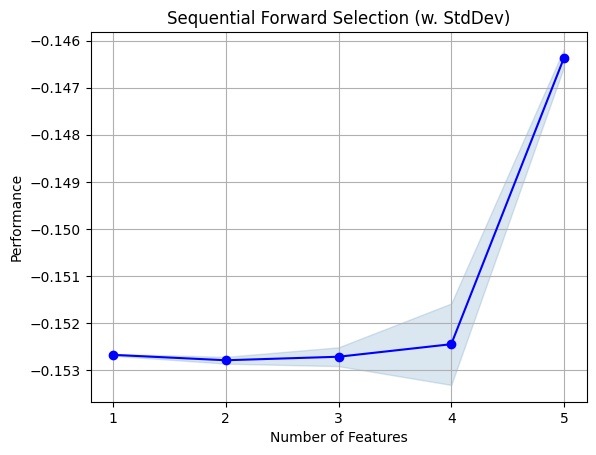

In [111]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()



In [114]:
sfs_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(sfs_idx)),
    ('model', regressor)
])

sfs_pipeline.fit(X_train, y_train)

Learning rate set to 0.07259
0:	learn: 0.4669926	total: 1.53ms	remaining: 1.53s
1:	learn: 0.4398993	total: 2.64ms	remaining: 1.31s
2:	learn: 0.4145848	total: 3.72ms	remaining: 1.24s
3:	learn: 0.3917114	total: 4.85ms	remaining: 1.21s
4:	learn: 0.3705357	total: 5.92ms	remaining: 1.18s
5:	learn: 0.3507744	total: 7.11ms	remaining: 1.18s
6:	learn: 0.3328090	total: 8.31ms	remaining: 1.18s
7:	learn: 0.3166159	total: 9.43ms	remaining: 1.17s
8:	learn: 0.3015085	total: 10.6ms	remaining: 1.17s
9:	learn: 0.2880807	total: 11.7ms	remaining: 1.16s
10:	learn: 0.2758320	total: 13.2ms	remaining: 1.19s
11:	learn: 0.2647008	total: 14.3ms	remaining: 1.18s
12:	learn: 0.2544131	total: 15.5ms	remaining: 1.17s
13:	learn: 0.2451585	total: 16.8ms	remaining: 1.18s
14:	learn: 0.2365752	total: 17.9ms	remaining: 1.18s
15:	learn: 0.2290377	total: 19.1ms	remaining: 1.17s
16:	learn: 0.2223368	total: 20.1ms	remaining: 1.16s
17:	learn: 0.2161120	total: 21.3ms	remaining: 1.16s
18:	learn: 0.2105449	total: 23.3ms	remaining:

,steps,"[('preprocessor', ...), ('rfe_extractor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [116]:
predictions_sfs = sfs_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_sfs)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_sfs)
metrics["mse"] = mean_squared_error(y_test, predictions_sfs)

metrics
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'rfe_sfs_feature_selection'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(sfs_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact('rfe_skl_cols.txt')
    mlflow.log_artifact('rfe_skl_idx.txt')
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 11:37:44 INFO mlflow.tracking._tracking_service.client: 🏃 View run rfe_sfs_feature_selection at: http://127.0.0.1:5000/#/experiments/1/runs/92d38dc0b70f48a0b278599c4c01bb2b.
2026/09/29 11:37:44 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


# HYPERPARAMS
## Gridsearch

In [117]:
from sklearn.model_selection import  GridSearchCV

In [118]:
param_grid = {
    'model__depth': [1,3,5]
}

In [119]:
gs = GridSearchCV(sfs_pipeline, param_grid, cv=2, scoring='neg_mean_absolute_error')
gs.fit(X_train, y_train)
print("Лучшие гиперпараметры:", gs.best_params_)

Learning rate set to 0.06506
0:	learn: 0.4749993	total: 1.64ms	remaining: 1.64s
1:	learn: 0.4576557	total: 2.12ms	remaining: 1.06s
2:	learn: 0.4416850	total: 2.59ms	remaining: 860ms
3:	learn: 0.4270311	total: 3ms	remaining: 748ms
4:	learn: 0.4131003	total: 3.47ms	remaining: 690ms
5:	learn: 0.4003078	total: 3.92ms	remaining: 650ms
6:	learn: 0.3882584	total: 4.41ms	remaining: 626ms
7:	learn: 0.3772304	total: 4.85ms	remaining: 601ms
8:	learn: 0.3665704	total: 5.34ms	remaining: 588ms
9:	learn: 0.3567096	total: 5.75ms	remaining: 569ms
10:	learn: 0.3477486	total: 6.2ms	remaining: 557ms
11:	learn: 0.3390035	total: 6.63ms	remaining: 546ms
12:	learn: 0.3307563	total: 7.08ms	remaining: 538ms
13:	learn: 0.3230829	total: 7.55ms	remaining: 532ms
14:	learn: 0.3155399	total: 7.99ms	remaining: 525ms
15:	learn: 0.3086659	total: 8.45ms	remaining: 520ms
16:	learn: 0.3022949	total: 8.93ms	remaining: 517ms
17:	learn: 0.2961049	total: 9.45ms	remaining: 515ms
18:	learn: 0.2904395	total: 10ms	remaining: 516ms

In [122]:
gs_pipeline  = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(sfs_idx)),
    ('model', CatBoostRegressor(depth=3))
])
gs_pipeline.fit(X_train, y_train)

Learning rate set to 0.07259
0:	learn: 0.4684419	total: 1.28ms	remaining: 1.28s
1:	learn: 0.4428413	total: 2.1ms	remaining: 1.05s
2:	learn: 0.4192738	total: 2.87ms	remaining: 954ms
3:	learn: 0.3977696	total: 3.83ms	remaining: 952ms
4:	learn: 0.3782263	total: 4.71ms	remaining: 938ms
5:	learn: 0.3598606	total: 5.48ms	remaining: 909ms
6:	learn: 0.3429261	total: 6.25ms	remaining: 887ms
7:	learn: 0.3275078	total: 7.11ms	remaining: 882ms
8:	learn: 0.3135030	total: 7.96ms	remaining: 877ms
9:	learn: 0.3010049	total: 9.04ms	remaining: 895ms
10:	learn: 0.2890334	total: 10.1ms	remaining: 912ms
11:	learn: 0.2786076	total: 11.2ms	remaining: 925ms
12:	learn: 0.2689099	total: 12.3ms	remaining: 936ms
13:	learn: 0.2601221	total: 13.3ms	remaining: 934ms
14:	learn: 0.2521667	total: 14.2ms	remaining: 931ms
15:	learn: 0.2446462	total: 15.9ms	remaining: 977ms
16:	learn: 0.2381806	total: 16.9ms	remaining: 975ms
17:	learn: 0.2319838	total: 18.7ms	remaining: 1.02s
18:	learn: 0.2264127	total: 19.8ms	remaining: 

,steps,"[('preprocessor', ...), ('rfe_extractor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [123]:
predictions_gs = gs_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_gs)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_gs)
metrics["mse"] = mean_squared_error(y_test, predictions_gs)

metrics
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'gs_run'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(gs_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 11:44:39 INFO mlflow.tracking._tracking_service.client: 🏃 View run gs_run at: http://127.0.0.1:5000/#/experiments/1/runs/b6fb80feeeb44171a11b26e5b65d6873.
2026/09/29 11:44:39 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


## Optuna

In [125]:
import optuna

/home/mainuser/my_proj/.venv_my_proj/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [128]:
def objective(trial):
    # предлагаем гиперпараметры
    depth = trial.suggest_int('depth', 1, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.1)

    # создаём и обучаем модель
    opt_pipeline  = Pipeline(steps=[
        ('preprocessor', preprocessor_sklearn), 
        ('rfe_extractor', ColumnExtractor(sfs_idx)),
        ('model', CatBoostRegressor(depth=depth, learning_rate=learning_rate, verbose=0))
    ])

    opt_pipeline.fit(X_train, y_train)

    # предсказываем и вычисляем RMSE
    preds = opt_pipeline.predict(X_test)
    mae =  mean_absolute_error(y_test, preds)   

    return mae

In [129]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# выводим результаты
print('Number of finished trials:', len(study.trials))
print('Best trial:', study.best_trial.params) 

[I 2026-09-29 11:46:06,426] A new study created in memory with name: no-name-5d0856cd-f964-49dd-b8bd-1db271b9548d
[I 2026-09-29 11:46:08,942] Trial 0 finished with value: 0.12505642767941497 and parameters: {'depth': 7, 'learning_rate': 0.08322453535160908}. Best is trial 0 with value: 0.12505642767941497.
[I 2026-09-29 11:46:11,895] Trial 1 finished with value: 0.12465356228429345 and parameters: {'depth': 8, 'learning_rate': 0.038910292021277756}. Best is trial 1 with value: 0.12465356228429345.
[I 2026-09-29 11:46:13,967] Trial 2 finished with value: 0.12410716704361749 and parameters: {'depth': 6, 'learning_rate': 0.007036297195413754}. Best is trial 2 with value: 0.12410716704361749.
[I 2026-09-29 11:46:15,501] Trial 3 finished with value: 0.12443066362924823 and parameters: {'depth': 4, 'learning_rate': 0.07463692034218603}. Best is trial 2 with value: 0.12410716704361749.
[I 2026-09-29 11:46:16,964] Trial 4 finished with value: 0.12403453322662983 and parameters: {'depth': 4, 'l

Number of finished trials: 10
Best trial: {'depth': 4, 'learning_rate': 0.021843977656553198}


In [130]:
opt_pipeline  = Pipeline(steps=[
    ('preprocessor', preprocessor_sklearn), 
    ('rfe_extractor', ColumnExtractor(sfs_idx)),
    ('model', CatBoostRegressor(depth=4, learning_rate=0.021844))
])
opt_pipeline.fit(X_train, y_train)


0:	learn: 0.4876584	total: 1.22ms	remaining: 1.22s
1:	learn: 0.4791955	total: 2.12ms	remaining: 1.05s
2:	learn: 0.4709234	total: 2.99ms	remaining: 994ms
3:	learn: 0.4628737	total: 3.82ms	remaining: 952ms
4:	learn: 0.4550034	total: 4.65ms	remaining: 926ms
5:	learn: 0.4473130	total: 5.49ms	remaining: 909ms
6:	learn: 0.4398532	total: 6.31ms	remaining: 895ms
7:	learn: 0.4325423	total: 7.13ms	remaining: 884ms
8:	learn: 0.4254348	total: 7.91ms	remaining: 871ms
9:	learn: 0.4184657	total: 8.7ms	remaining: 862ms
10:	learn: 0.4116625	total: 9.57ms	remaining: 861ms
11:	learn: 0.4050326	total: 10.5ms	remaining: 861ms
12:	learn: 0.3984626	total: 11.3ms	remaining: 857ms
13:	learn: 0.3921613	total: 12.2ms	remaining: 858ms
14:	learn: 0.3859771	total: 13ms	remaining: 856ms
15:	learn: 0.3799566	total: 13.9ms	remaining: 854ms
16:	learn: 0.3741199	total: 14.7ms	remaining: 851ms
17:	learn: 0.3684045	total: 16.1ms	remaining: 877ms
18:	learn: 0.3628625	total: 16.9ms	remaining: 874ms
19:	learn: 0.3574029	tota

,steps,"[('preprocessor', ...), ('rfe_extractor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [131]:
predictions_opt = opt_pipeline.predict(X_test)

metrics = {}
metrics["mae"] = mean_absolute_error(y_test, predictions_opt)   
metrics["mape"] = mean_absolute_percentage_error(y_test, predictions_opt)
metrics["mse"] = mean_squared_error(y_test, predictions_opt)

metrics
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'opt_run'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(opt_pipeline, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 11:47:59 INFO mlflow.tracking._tracking_service.client: 🏃 View run opt_run at: http://127.0.0.1:5000/#/experiments/1/runs/7334599dc4fc43c586759d29dc17ef00.
2026/09/29 11:47:59 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.


Лучшая модель FE_Sklearn

In [132]:
best_model = pipeline_sklearn.fit(df.drop(columns=['target'], axis=1), df['target'])

Learning rate set to 0.075966
0:	learn: 0.4650096	total: 5.9ms	remaining: 5.89s
1:	learn: 0.4358725	total: 8.62ms	remaining: 4.3s
2:	learn: 0.4094435	total: 11.5ms	remaining: 3.81s
3:	learn: 0.3851192	total: 17.9ms	remaining: 4.46s
4:	learn: 0.3629067	total: 22.1ms	remaining: 4.4s
5:	learn: 0.3424974	total: 25.3ms	remaining: 4.19s
6:	learn: 0.3239454	total: 28.9ms	remaining: 4.1s
7:	learn: 0.3073599	total: 32.7ms	remaining: 4.05s
8:	learn: 0.2926044	total: 36.5ms	remaining: 4.02s
9:	learn: 0.2789611	total: 41.8ms	remaining: 4.13s
10:	learn: 0.2667303	total: 46.2ms	remaining: 4.16s
11:	learn: 0.2555440	total: 50.7ms	remaining: 4.18s
12:	learn: 0.2454386	total: 58.7ms	remaining: 4.45s
13:	learn: 0.2364085	total: 62.9ms	remaining: 4.43s
14:	learn: 0.2284045	total: 67ms	remaining: 4.4s
15:	learn: 0.2210826	total: 70.3ms	remaining: 4.32s
16:	learn: 0.2146913	total: 73.3ms	remaining: 4.24s
17:	learn: 0.2088767	total: 80.2ms	remaining: 4.37s
18:	learn: 0.2037857	total: 84.5ms	remaining: 4.36s

In [135]:
best_pred = best_model.predict(df.drop(columns=['target'], axis=1)) 
metrics = {}
metrics["mae"] = mean_absolute_error(df['target'], best_pred)   
metrics["mape"] = mean_absolute_percentage_error(df['target'], best_pred)
metrics["mse"] = mean_squared_error(df['target'], best_pred)

metrics

{'mae': 0.10426794697192006,
 'mape': 0.03235845134325693,
 'mse': 0.017702258290867755}

In [136]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id
RUN_NAME = 'best_model'

with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id) as run:
    # получаем уникальный идентификатор запуска эксперимента
    run_id = run.info.run_id 
    mlflow.sklearn.log_model(best_model, 
                             artifact_path="models",
                             signature=signature,
                             input_example=input_example,
                             pip_requirements=req_file
                             )
    mlflow.log_metrics(metrics)
    mlflow.log_artifact(art)
    mlflow.log_params(model_sklearn.get_params())

run = mlflow.get_run(run_id) 
assert (run.info.status =='FINISHED')

2026/09/29 11:54:05 INFO mlflow.tracking._tracking_service.client: 🏃 View run best_model at: http://127.0.0.1:5000/#/experiments/1/runs/356b693b37c5439db5506629f32512d4.
2026/09/29 11:54:05 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1.
